Import libraries:

In [4]:
!pip install pandas numpy seaborn matplotlib scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

导入数据

In [ ]:
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
df = pd.read_csv(filepath,)

1. 线性回归和多重线性回归

1.1简单线性模型

In [10]:
#导入模型
from sklearn.linear_model import LinearRegression

In [11]:
#创建线性回归的对象
lm = LinearRegression()
lm
X = df[['highway-mpg']] ## 2D，作为特征矩阵 X ✔ df[['highway-mpg']]（两层中括号）得到的是 DataFrame（二维，形状是 (n_samples, 1)）。
Y = df['price'] #  # 1D，作为目标向量 y ✔

In [12]:
#拟合模型
lm.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
#得到预测值
Yhat=lm.predict(X)
Yhat[0:5]  

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [14]:
#得到截距 What is the value of the intercept (a)?
lm.intercept_

np.float64(38423.30585815743)

In [15]:
#得到斜率 What is the value of the slope (b)?
lm.coef_

array([-821.73337832])

1.2 复杂线性模型

In [16]:
#设定变量
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

In [17]:
#拟合
lm.fit(Z, df['price'])
lm.intercept_
lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

2. 模型评估和可视化

In [18]:
# import the visualization package: seaborn
import seaborn as sns
%matplotlib inline 

(0.0, 48179.2880228289)

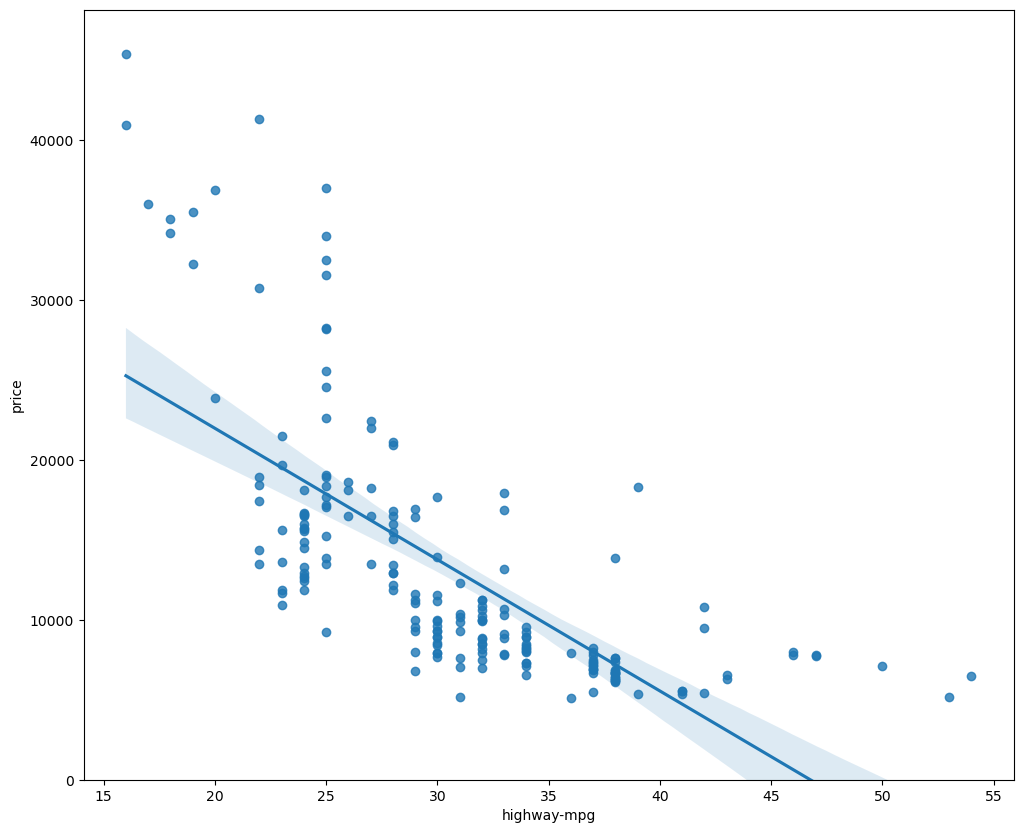

In [19]:
#画回归图
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

(0.0, 47414.1)

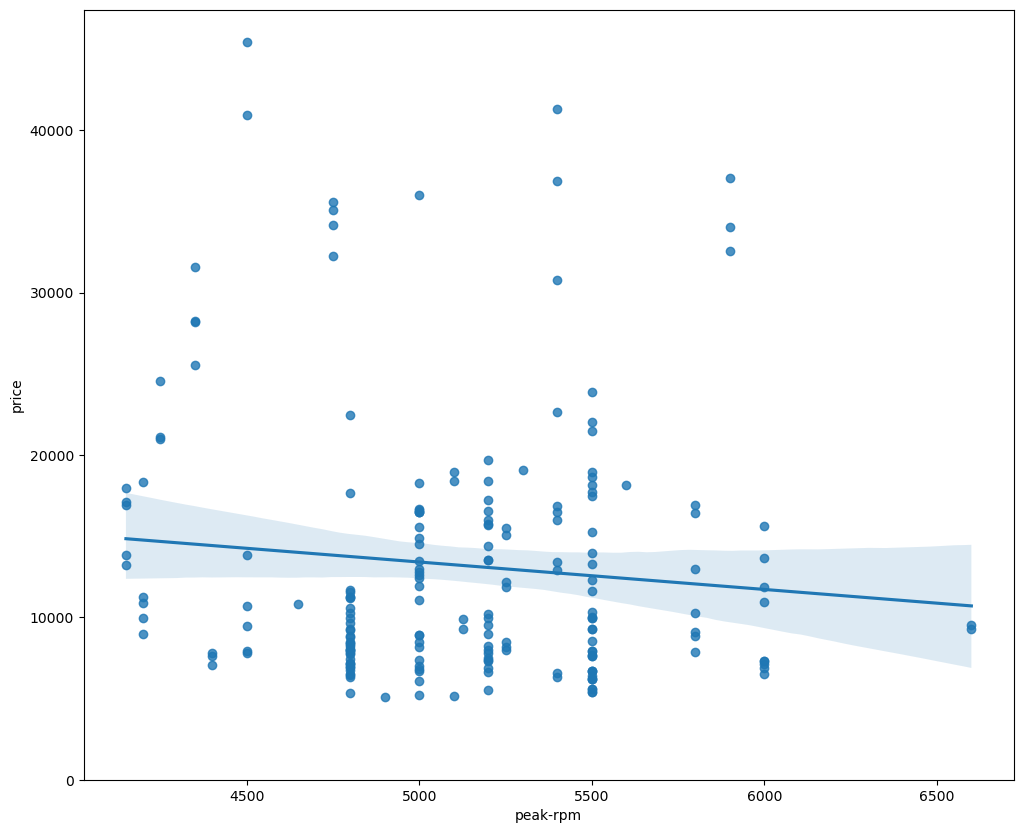

In [20]:
#再画一个
plt.figure(figsize=(width, height))
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)

In [21]:
#检查相关性
df[["peak-rpm","highway-mpg","price"]].corr()

,peak-rpm,highway-mpg,price
peak-rpm,1.000000,-0.058598,-0.101616
highway-mpg,-0.058598,1.000000,-0.704692
price,-0.101616,-0.704692,1.000000


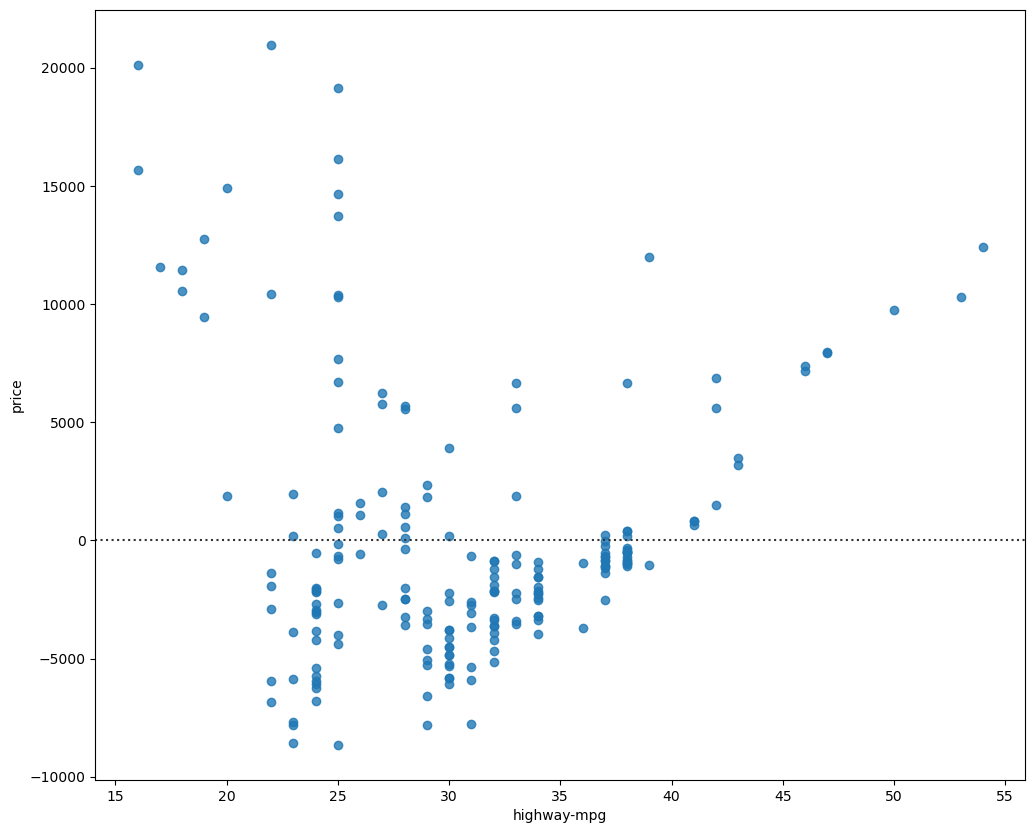

In [22]:
#画残差图
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

多重线性回归的可视化

In [23]:
Y_hat = lm.predict(Z)
plt.figure(figsize=(width, height)) #创建一个画布

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15588\575945439.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15588\575945439.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

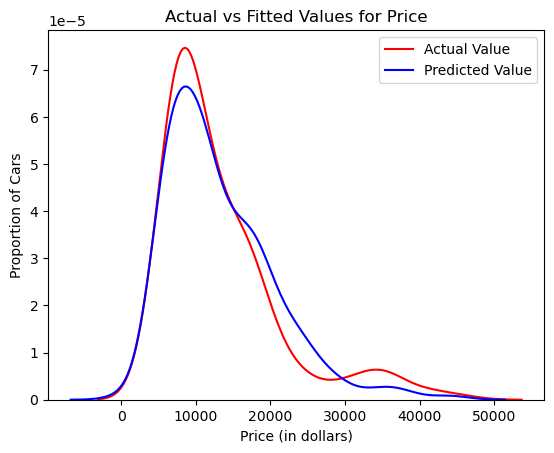

In [28]:
#sns.distplot(...)：画“分布图” hist=False：不画柱状直方图，只画一条平滑的密度曲线 label="Actual Value"：给这条红色曲线起图例名字“Actual Value”（真实值）。。
ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')
plt.legend(['Actual Value', 'Predicted Value'])

plt.show()
plt.close()

3.多项式回归和pipelines

In [29]:
#画多项式的图
#定义一个函数，名字叫 PlotPolly。model：多项式模型，一般是 np.poly1d(p) 这样的对象，可以像函数一样 model(x) 得到预测值。independent_variable：自变量的原始数据（例如车长 length）。dependent_variabble：因变量的原始数据（例如价格 price）。Name：自变量的名字，用来作为 x 轴标签。
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100) #生成一组等间距的自变量取值，从 15 到 55，一共 100 个点
    y_new = model(x_new)  #把这 100 个 x_new 代入多项式模型 model，得到对应的预测值 y_new。

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-') #原始散点，用 '.' 表示每个点画成小点。'-'：拟合出来的曲线，用 '-' 画成连线。
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length') #设置图标题
    ax = plt.gca() #plt.gca() 获取当前的 坐标轴对象（Axes）。把它存到变量 ax，后面用来改背景颜色。
    ax.set_facecolor((0.898, 0.898, 0.898)) #设置坐标轴区域的背景颜色，这里用的是一个 RGB 三元组，值在 0~1 之间。
    fig = plt.gcf() #plt.gcf() 获取当前的 Figure（整张画布对象），并赋值给 fig。
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()


In [30]:
#获取变量 出自变量和因变量
x = df['highway-mpg']
y = df['price']

In [32]:
#使用 polyfit 函数拟合多项式，然后使用 poly1d 函数显示多项式函数。
f = np.polyfit(x, y, 3)
p = np.poly1d(f) #np.poly1d(f) 把刚才那组系数 f 封装成一个 多项式对象  像函数一样使用：p(30) 得到某个 x 下的预测 y。
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


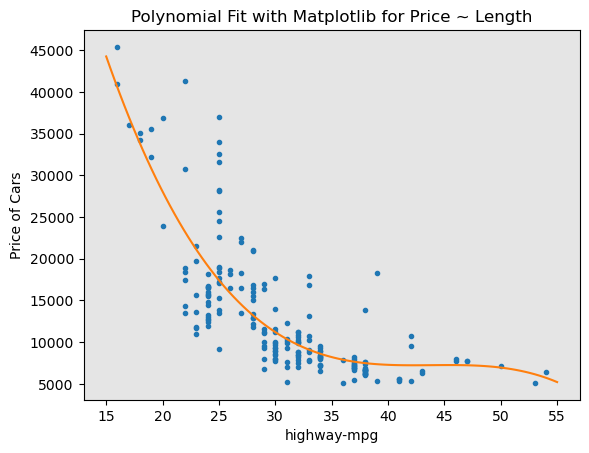

In [33]:
PlotPolly(p, x, y, 'highway-mpg') #把刚才得到的多项式模型 p、原始数据 x、y，以及 x 轴名字 'highway-mpg' 传给你前面定义的 PlotPolly 函数。

In [34]:
#我们可以对多个特征进行多项式变换。首先，我们导入该模块：
from sklearn.preprocessing import PolynomialFeatures
#我们创建一个 2 次多项式特征对象：
pr=PolynomialFeatures(degree=2)
pr
Z_pr=pr.fit_transform(Z)
Z.shape
Z_pr.shape

(201, 15)

In [35]:
#Pipeline
#数据管道简化了数据处理步骤。我们使用 Pipeline 模块创建管道。我们还在管道中使用 StandardScaler 作为其中的一个步骤。
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
#我们通过创建一个元组列表来创建管道，该列表包含模型或估计器的名称及其对应的构造函数。
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
#我们将列表作为参数传递给管道构造函数：
pipe=Pipeline(Input)
pipe
#首先，我们将数据类型 Z 转换为 float 类型，以避免 StandardScaler 接受 float 输入时可能出现的转换警告。
#然后，我们可以同时对数据进行归一化、变换并拟合模型。
Z = Z.astype(float)
pipe.fit(Z,y)
#类似地，我们可以同时对数据进行归一化、转换和预测。
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

4. Measures for In-Sample Evaluation

4.1 Model 1: Simple Linear Regression

In [36]:
#计算 R^2
lm.fit(X, Y)
# Find the R^2
print('The R-square is: ', lm.score(X, Y))

The R-square is:  0.4965911884339176


In [38]:
#计算MSE
Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]


In [39]:
#让我们从 metrics 模块导入 mean_squared_error 函数：
from sklearn.metrics import mean_squared_error
#我们可以将预测结果与实际结果进行比较：
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  31635042.944639888


4.2 Model 2: Multiple Linear Regression

In [40]:
# fit the model 
lm.fit(Z, df['price'])
# Find the R^2
print('The R-square is: ', lm.score(Z, df['price']))

The R-square is:  0.8093562806577458


In [41]:
Y_predict_multifit = lm.predict(Z)
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The mean square error of price and predicted value using multifit is:  11980366.870726489


4.3 Model 3: Polynomial Fit

In [42]:
from sklearn.metrics import r2_score
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)
mean_squared_error(df['price'], p(x))

The R-square value is:  0.674194666390652


20474146.426361207

5. Prediction and Decision Making·

In [43]:
#在上一节中，我们使用 `fit` 方法训练了模型。现在我们将使用 `predict` 方法进行预测。首先导入 pyplot 进行绘图；我们还会用到一些来自 numpy 的函数。
import matplotlib.pyplot as plt
import numpy as np

d:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


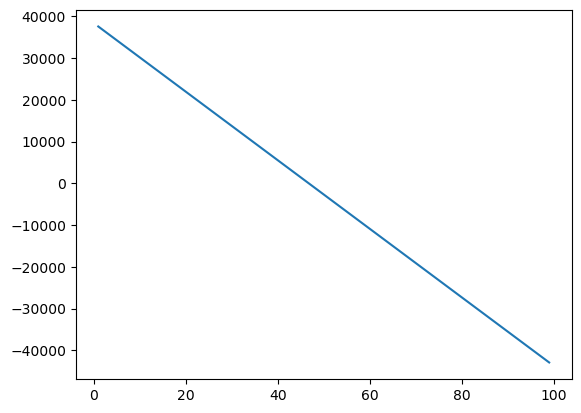

In [44]:
%matplotlib inline 

new_input=np.arange(1, 100, 1).reshape(-1, 1)

lm.fit(X, Y)
lm

yhat=lm.predict(new_input)
yhat[0:5]

plt.plot(new_input, yhat)
plt.show()